<a href="https://colab.research.google.com/github/ahmedhasannaqvi110-prog/bmen600_testhtml/blob/main/oasis3_future_risk_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Future Cognitive Risk Scale (OASIS-3)

**Research question:** can MRI brain measurement combined with risk factors produce a likelihood-ratio scale that identifies cognitively normal adults at higher risk of future cognitive impairment?

| Step | What it does |
|---|---|
| 0 | Setup: mount Google Drive, unzip the OASIS-3 files |
| 1 | Build the cohort: cognitively normal (CDR 0) adults at an MRI (all ages, 42–97), followed for conversion to CDR ≥ 0.5 |
| 2 | Cross-check conversions against the official OASIS "always normal" list |
| 3 | Compare models (C-index), including whole-brain vs. hippocampal volume |
| 4 | Screen other recorded risk factors |
| 5 | Build the points scale (Sullivan method) |
| 6 | Cross-validated likelihood ratios, risk groups, 5-year risk and figures |
| 7 | Score a patient |

**Data:** OASIS-3 is restricted. Each person running this notebook needs their own approved OASIS-3 access and must keep the files private (do not share the Drive folder or commit data to GitHub).
Put **`OASIS3_data_files.zip`** and **`OASIS_cohort_files.zip`** (downloaded from NITRC-IR → OASIS3 → `OAS_data_files`) anywhere in your Google Drive.

Runs on a standard CPU runtime in about 5–10 minutes; no GPU needed.

In [ ]:
# ---- settings
DRIVE_DIR = "/content/drive/MyDrive"   # searched recursively for the two zip files
HORIZON = 5.0                          # years, for likelihood ratios and risk groups
SEED = 0

In [ ]:
import os, sys, zipfile, glob
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import RepeatedStratifiedKFold
from statsmodels.duration.hazard_regression import PHReg
import warnings; warnings.filterwarnings("ignore")

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    WORK = Path("/content/oasis3")
else:  # local run
    DRIVE_DIR = os.environ.get("DRIVE_DIR", DRIVE_DIR)
    WORK = Path(os.environ.get("WORK_DIR", "oasis3_work"))
WORK.mkdir(parents=True, exist_ok=True)
RESULTS = WORK / "results"; RESULTS.mkdir(exist_ok=True)

def find_and_unzip(name):
    hits = sorted(Path(DRIVE_DIR).rglob(name))
    if not hits:
        raise FileNotFoundError(f"'{name}' not found under {DRIVE_DIR}. Upload it to your Drive.")
    with zipfile.ZipFile(hits[0]) as z:
        z.extractall(WORK)
    print(f"unzipped {hits[0]}")

if not (WORK / "OASIS3_data_files").exists(): find_and_unzip("OASIS3_data_files.zip")
if not (WORK / "OASIS_cohort_files").exists(): find_and_unzip("OASIS_cohort_files.zip")
SCANS = WORK / "OASIS3_data_files" / "scans"

def read(folder_prefix, file_name):
    path = next(SCANS.glob(f"{folder_prefix}*/resources/csv/files/{file_name}"))
    return pd.read_csv(path, low_memory=False)

demo = read("demo-", "OASIS3_demographics.csv")
cdr = read("UDSb4-", "OASIS3_UDSb4_cdr.csv")
hh = read("UDSa5-", "OASIS3_UDSa5_health_history.csv")
phys = read("UDSb1-", "OASIS3_UDSb1_physical_eval.csv")
gds = read("UDSb6-", "OASIS3_UDSb6_gds.csv")
fs = read("FS-", "OASIS3_Freesurfer_output.csv")
print("participants:", demo.OASISID.nunique(), "| clinical visits:", len(cdr), "| FreeSurfer runs:", len(fs))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
participants: 1378 | clinical visits: 8626 | FreeSurfer runs: 2681


## 1. Build the cohort
* **Baseline** = each person's first FreeSurfer MRI (QC passed) at which they were **CDR 0** (clinical visit within 1 year of the scan). All ages are included (OASIS-3 starts at 42).
* **Event** = first later visit with **CDR ≥ 0.5**; otherwise censored at the last visit.
* **Brain measures** (FreeSurfer, divided by intracranial volume): whole-brain volume fraction (an nWBV equivalent) and hippocampal volume.
* **Factors** come from the health-history and physical forms closest to the scan (within 2 years). UDS coding: 0 absent, 1 recent/active, 2 remote/inactive, 9 unknown.
* One row per person, so cross-validation is participant-level by construction.

In [ ]:
fs = fs.copy()
fs["day"] = fs.MR_session.str.extract(r"_d(\d+)").astype(float)[0]
fs = fs[fs["FS QC Status"].astype(str).str.lower().str.startswith("pass")].copy()
fs["nwbv_fs"] = (fs.CortexVol + fs.SubCortGrayVol + fs.CorticalWhiteMatterVol) / fs.IntraCranialVol
fs["hippo_icv"] = fs.TOTAL_HIPPOCAMPUS_VOLUME / fs.IntraCranialVol * 1000
cdr = cdr.dropna(subset=["CDRTOT", "days_to_visit"]).sort_values(["OASISID", "days_to_visit"])

def nearest_row(t, day, max_days):
    if t.empty: return None
    i = (t.days_to_visit - day).abs().idxmin()
    return t.loc[i] if abs(t.days_to_visit[i] - day) <= max_days else None

cdr_by, hh_by, ph_by, gds_by = (dict(tuple(x.groupby("OASISID"))) for x in (cdr, hh, phys, gds))
rows = []
for sid, scans in fs.sort_values("day").groupby("Subject"):
    visits = cdr_by.get(sid, pd.DataFrame(columns=cdr.columns))
    for _, s in scans.iterrows():
        v = nearest_row(visits, s.day, 365)
        if v is None or v.CDRTOT != 0: continue
        later = visits[visits.days_to_visit > s.day + 30]
        if later.empty: break
        hit = later[later.CDRTOT >= 0.5]
        event = int(not hit.empty)
        end_day = hit.days_to_visit.iloc[0] if event else later.days_to_visit.iloc[-1]
        h = nearest_row(hh_by.get(sid, pd.DataFrame(columns=hh.columns)), s.day, 730)
        p = nearest_row(ph_by.get(sid, pd.DataFrame(columns=phys.columns)), s.day, 730)
        g = nearest_row(gds_by.get(sid, pd.DataFrame(columns=gds.columns)), s.day, 730)
        get = lambda r, c: (r[c] if r is not None else np.nan)
        rows.append({"OASISID": sid, "scan_day": s.day, "age": v["age at visit"], "event": event,
                     "years": (end_day - s.day) / 365.25, "nwbv_fs": s.nwbv_fs, "hippo_icv": s.hippo_icv,
                     **{c: get(h, c) for c in ["HYPERTEN", "DIABETES", "HYPERCHO", "CBSTROKE", "CBTIA", "DEP2YRS", "TOBAC100"]},
                     **{c: get(p, c) for c in ["BPSYS", "WEIGHT", "HEIGHT", "HEARING"]},
                     "GDS": get(g, "GDS")})
        break

d = pd.DataFrame(rows).merge(demo[["OASISID", "GENDER", "EDUC", "APOE", "daddem", "momdem"]], on="OASISID", how="left")
yes = lambda s: s.map(lambda v: 1.0 if v in (1, 2) else (0.0 if v == 0 else np.nan))
d["hypertension"] = yes(d.HYPERTEN)
d["depression_2yrs"] = d.DEP2YRS.map({0: 0.0, 1: 1.0})
d["apoe4"] = d.APOE.map(lambda a: np.nan if pd.isna(a) or a == 0 else float("4" in str(int(a))))
d["female"] = (d.GENDER == 2).astype(float)
d["diabetes"], d["high_cholesterol"] = yes(d.DIABETES), yes(d.HYPERCHO)
d["stroke_tia"] = np.fmax(yes(d.CBSTROKE), yes(d.CBTIA))
d["smoked_100_cigs"] = d.TOBAC100.map({0: 0.0, 1: 1.0})
w, h = d.WEIGHT.where(d.WEIGHT.between(70, 450)), d.HEIGHT.where(d.HEIGHT.between(48, 84))
d["bmi"] = 703 * w / h ** 2
d["hearing_problem"] = d.HEARING.map({1: 0.0, 0: 1.0})
d["gds_depression_score"] = d.GDS.where(d.GDS.between(0, 15))
fam = d[["daddem", "momdem"]].replace({5: np.nan, 9: np.nan})
d["family_history"] = fam.max(axis=1).where(fam.notna().any(axis=1))

print(f"cognitively normal at an MRI with follow-up: {len(d)} people (ages {d.age.min():.0f}-{d.age.max():.0f})")
print(f"converted to CDR >= 0.5: {d.event.sum()} ({d.event.mean():.1%}); median follow-up {d.years.median():.1f} years")
d.groupby("event")[["age", "EDUC", "hypertension", "BPSYS", "apoe4", "depression_2yrs", "nwbv_fs", "hippo_icv"]].mean().round(3)

cognitively normal at an MRI with follow-up: 909 people (ages 42-97)
converted to CDR >= 0.5: 225 (24.8%); median follow-up 5.3 years


,age,EDUC,hypertension,BPSYS,apoe4,depression_2yrs,nwbv_fs,hippo_icv
event,,,,,,,,
0,67.296,16.177,0.434,128.184,0.344,0.168,0.624,5.296
1,74.116,15.791,0.513,134.399,0.372,0.314,0.601,4.710


## 2. Cross-check against the official 'always cognitively normal' list

In [ ]:
normal_list = pd.read_csv(next((WORK / "OASIS_cohort_files").rglob("*.csv")))
d["in_always_normal_list"] = d.OASISID.isin(set(normal_list.OASIS3_id))
pd.crosstab(d.event.map({0: "did not convert", 1: "converted"}), d.in_always_normal_list)

in_always_normal_list,False,True
event,,
converted,225,0
did not convert,23,661


## 3. Compare models
Brain measures are converted to **age-normalised z-scores** against people who did not convert, with the norm re-fitted inside each training fold.
Cox proportional hazards; **Harrell's C** (0.5 = chance) from 10-fold cross-validation repeated 5 times.

In [ ]:
def fit_norm(train, col):
    ref = train[train.event == 0]
    sl, ic = np.polyfit(ref.age, ref[col], 1)
    return sl, ic, np.std(ref[col] - (ic + sl * ref.age), ddof=2)

def zscore(x, col, norm):
    sl, ic, sd = norm
    return (x[col] - (ic + sl * x.age)) / sd

def harrell_c(time, event, risk):
    num = den = 0.0
    for i in np.where(event == 1)[0]:
        r = time > time[i]
        den += r.sum(); num += (risk[i] > risk[r]).sum() + 0.5 * (risk[i] == risk[r]).sum()
    return num / den

def cv_c(df, cols, reps=5, seed=SEED):
    df = df.reset_index(drop=True)
    splits = list(RepeatedStratifiedKFold(n_splits=10, n_repeats=reps, random_state=seed).split(df, df.event))
    out = []
    for r in range(reps):
        risk = np.zeros(len(df))
        for tr, te in splits[r * 10:(r + 1) * 10]:
            a, b = df.iloc[tr].copy(), df.iloc[te].copy()
            for col, z in (("nwbv_fs", "z_wb"), ("hippo_icv", "z_hip")):
                nm = fit_norm(a, col); a[z], b[z] = zscore(a, col, nm), zscore(b, col, nm)
            mu, sd = a[cols].mean(), a[cols].std()
            fit = PHReg(a.years, (a[cols] - mu) / sd, status=a.event).fit(disp=0)
            risk[te] = ((b[cols] - mu) / sd).values @ fit.params
        out.append(harrell_c(df.years.values, df.event.values, risk))
    return np.mean(out), np.min(out), np.max(out)

m = d.copy()
m["hypertension"] = m.hypertension.fillna(m.hypertension.mode()[0])
models = {
    "age only": ["age"],
    "age + education + hypertension": ["age", "EDUC", "hypertension"],
    "+ whole-brain volume (z)": ["z_wb", "age", "EDUC", "hypertension"],
    "+ hippocampal volume (z)": ["z_hip", "age", "EDUC", "hypertension"],
    "+ both brain measures": ["z_wb", "z_hip", "age", "EDUC", "hypertension"],
}
pd.DataFrame({k: cv_c(m, v) for k, v in models.items()}, index=["C mean", "C min", "C max"]).T.round(3)

,C mean,C min,C max
age only,0.739,0.738,0.740
age + education + hypertension,0.738,0.736,0.739
+ whole-brain volume (z),0.739,0.737,0.741
+ hippocampal volume (z),0.756,0.754,0.757
+ both brain measures,0.755,0.753,0.757


## 4. Screen other recorded risk factors
Each candidate is added to the core model (age, education, hypertension, hippocampal z). Complete cases for each candidate.
Cognitive test scores (MMSE etc.) are excluded on purpose: they measure early symptoms, not risk factors.

In [ ]:
CORE = ["age", "EDUC", "hypertension", "z_hip"]
CANDS = ["apoe4", "family_history", "female", "diabetes", "high_cholesterol", "stroke_tia", "depression_2yrs",
         "gds_depression_score", "smoked_100_cigs", "bmi", "hearing_problem"]
screen = []
for c in CANDS:
    sub = d.dropna(subset=["hypertension", c]).reset_index(drop=True)
    full = sub.copy(); full["z_hip"] = zscore(full, "hippo_icv", fit_norm(full, "hippo_icv"))
    X = full[CORE + [c]]
    fit = PHReg(full.years, (X - X.mean()) / X.std(), status=full.event).fit(disp=0)
    per = 1.0 if sub[c].nunique() <= 2 else X[c].std()          # binary: yes vs no; continuous: per SD
    beta, (lo, hi) = fit.params[-1] / X[c].std() * per, fit.conf_int()[-1] / X[c].std() * per
    c0, c1 = cv_c(sub, CORE, reps=3)[0], cv_c(sub, CORE + [c], reps=3)[0]
    screen.append({"factor": c, "n": len(sub), "HR": np.exp(beta), "CI low": np.exp(lo), "CI high": np.exp(hi),
                   "p": fit.pvalues[-1], "C core": c0, "C with factor": c1, "gain": c1 - c0})
screen = pd.DataFrame(screen).set_index("factor")
screen.to_csv(RESULTS / "candidate_screen.csv")
screen.round(3).sort_values("gain", ascending=False)

,n,HR,CI low,CI high,p,C core,C with factor,gain
factor,,,,,,,,
depression_2yrs,785,2.067,1.519,2.814,0.000,0.746,0.760,0.015
gds_depression_score,792,1.280,1.137,1.440,0.000,0.748,0.763,0.015
apoe4,791,1.542,1.150,2.067,0.004,0.749,0.757,0.007
family_history,782,1.315,0.978,1.767,0.069,0.748,0.750,0.002
hearing_problem,772,1.302,0.877,1.934,0.191,0.749,0.749,0.000
smoked_100_cigs,778,1.151,0.864,1.533,0.337,0.749,0.748,-0.000
stroke_tia,795,1.742,0.984,3.085,0.057,0.748,0.748,-0.000
female,795,0.933,0.690,1.261,0.652,0.748,0.747,-0.002
high_cholesterol,787,1.044,0.778,1.401,0.776,0.748,0.746,-0.002


## 5. Build the points scale
Factors: **age, hippocampal volume for age, education, hypertension, depression in the last 2 years, APOE ε4.**
Sullivan method: **1 point = the hazard of 5 extra years of age.** Complete cases only.

In [ ]:
FACTORS = ["age", "EDUC", "hypertension", "z_hip", "depression_2yrs", "apoe4"]
s = d.dropna(subset=["hypertension", "depression_2yrs", "apoe4"]).reset_index(drop=True)
NORM = fit_norm(s, "hippo_icv")
s["z_hip"] = zscore(s, "hippo_icv", NORM)
cox = PHReg(s.years, s[FACTORS], status=s.event).fit(disp=0)
b = pd.Series(cox.params, index=FACTORS)
print(f"complete cases: {len(s)}, converters: {s.event.sum()}")
print("healthy-ageing hippocampal norm: expected = %.4f %+.6f x age, SD %.4f" % (NORM[1], NORM[0], NORM[2]))
display(pd.DataFrame({"HR": np.exp(b), "CI low": np.exp(cox.conf_int()[:, 0]), "CI high": np.exp(cox.conf_int()[:, 1]),
                      "p": cox.pvalues}, index=FACTORS).round(3))

B = 5 * b["age"]
AGE_BANDS = [(0, 50, 47.5), (50, 55, 52.5), (55, 60, 57.5), (60, 65, 62.5), (65, 70, 67.5),
             (70, 75, 72.5), (75, 80, 77.5), (80, 85, 82.5), (85, 120, 87.5)]
HIP_BANDS = [(-np.inf, -2, -2.5), (-2, -1, -1.5), (-1, 0, -0.5), (0, 1, 0.5), (1, np.inf, 1.5)]
EDU_BANDS = [(0, 13, 12), (13, 16, 14), (16, 17, 16), (17, 40, 18)]
PTS_AGE = [int(round(b["age"] * (mid - 47.5) / B)) for *_, mid in AGE_BANDS]
PTS_HIP = [int(round(b["z_hip"] * (mid - 1.5) / B)) for *_, mid in HIP_BANDS]
PTS_EDU = [int(round(b["EDUC"] * (mid - 18) / B)) for *_, mid in EDU_BANDS]
PTS_BIN = {f: int(round(b[f] / B)) for f in ("hypertension", "depression_2yrs", "apoe4")}
print("points  age <50, 50-54 .. 85+:", PTS_AGE, "| hippocampus <-2..>+1 SD:", PTS_HIP,
      "| education <=12/13-15/16/>16 yrs:", PTS_EDU, "| yes/no:", PTS_BIN)

def band_pts(v, bands, pts):
    return next(p for (lo, hi, _), p in zip(bands, pts) if lo <= v < hi)

def score(x, norm):
    z = zscore(x, "hippo_icv", norm)
    return (x.age.map(lambda v: band_pts(v, AGE_BANDS, PTS_AGE)) + z.map(lambda v: band_pts(v, HIP_BANDS, PTS_HIP))
            + x.EDUC.map(lambda v: band_pts(v, EDU_BANDS, PTS_EDU))
            + sum(x[f].astype(int) * p for f, p in PTS_BIN.items()))

s["score"] = score(s, NORM)
s["y5"] = np.where((s.event == 1) & (s.years <= HORIZON), 1, np.where(s.years >= HORIZON, 0, np.nan))

complete cases: 782, converters: 190
healthy-ageing hippocampal norm: expected = 7.8381 -0.037608 x age, SD 0.6836


,HR,CI low,CI high,p
age,1.096,1.076,1.116,0.000
EDUC,0.955,0.903,1.011,0.112
hypertension,1.045,0.781,1.399,0.766
z_hip,0.605,0.513,0.712,0.000
depression_2yrs,1.993,1.461,2.718,0.000
apoe4,1.477,1.099,1.985,0.010


points  age <50, 50-54 .. 85+: [0, 1, 2, 3, 4, 5, 6, 7, 8] | hippocampus <-2..>+1 SD: [4, 3, 2, 1, 0] | education <=12/13-15/16/>16 yrs: [1, 0, 0, 0] | yes/no: {'hypertension': 0, 'depression_2yrs': 2, 'apoe4': 1}


## 6. Cross-validated likelihood ratios
The hippocampal norm is re-fitted in each training fold and the score is computed on the held-out fold (point weights fixed).
**LR = P(score band | converted within 5 years) ÷ P(score band | not converted by 5 years).** People followed for less than 5 years without converting are excluded from the LR table.
95% CIs: bootstrap over people. Observed 5-year risk per group: Kaplan–Meier (uses everyone).

In [ ]:
splits = list(RepeatedStratifiedKFold(n_splits=10, n_repeats=5, random_state=SEED).split(s, s.event))
oof = np.zeros((5, len(s)))
for i, (tr, te) in enumerate(splits):
    oof[i // 10, te] = score(s.iloc[te], fit_norm(s.iloc[tr], "hippo_icv"))
y5 = s.y5.values; known = ~np.isnan(y5)
print(f"5-year outcome known for {known.sum()} people ({int(np.nansum(y5))} converted within {HORIZON:g} years)")
print(f"5-year AUC: apparent {roc_auc_score(y5[known], s.score[known]):.3f}, "
      f"cross-validated {np.mean([roc_auc_score(y5[known], o[known]) for o in oof]):.3f}")

GROUPS = [("Low", 0, 7), ("Medium", 8, 9), ("High", 10, 16)]   # cut where score-band LRs cross 1
BANDS = [("0-4", 0, 4), ("5-6", 5, 6), ("7", 7, 7), ("8-9", 8, 9), ("10", 10, 10), ("11-16", 11, 16)]

def lr_table(scores, y, cuts):
    pos, neg = (y == 1).sum(), (y == 0).sum(); rows = []
    for name, lo, hi in cuts:
        inb = (scores >= lo) & (scores <= hi)
        a, c = (inb & (y == 1)).sum(), (inb & (y == 0)).sum()
        rows.append({"band": name, "converted": a, "not_converted": c, "LR": (a / pos) / (c / neg) if c else np.inf})
    return pd.DataFrame(rows).set_index("band")

def cv_lr(cuts):
    t = pd.concat([lr_table(o[known], y5[known], cuts) for o in oof]).groupby("band", sort=False)[["converted", "not_converted"]].mean()
    pos, neg = (y5[known] == 1).sum(), (y5[known] == 0).sum()
    t["LR"] = (t.converted / pos) / (t.not_converted / neg)
    rng = np.random.default_rng(SEED); sc, yy = oof[0][known], y5[known]; boots = []
    for _ in range(2000):
        i = rng.integers(0, len(sc), len(sc))
        boots.append(lr_table(sc[i], yy[i], cuts).LR.replace(np.inf, np.nan).values)
    t["LR low"], t["LR high"] = np.nanpercentile(boots, 2.5, 0), np.nanpercentile(boots, 97.5, 0)
    return t

def km_risk(time, event, horizon=HORIZON):
    surv = 1.0
    for t_ in np.sort(np.unique(time[(event == 1) & (time <= horizon)])):
        surv *= 1 - ((time == t_) & (event == 1)).sum() / (time >= t_).sum()
    return 1 - surv

groups, bands = cv_lr(GROUPS), cv_lr(BANDS)
sc_all = s.score.values
groups["share of people"] = [((sc_all >= lo) & (sc_all <= hi)).mean() for _, lo, hi in GROUPS]
groups["observed 5-yr risk"] = [km_risk(s.years.values[(sc_all >= lo) & (sc_all <= hi)], s.event.values[(sc_all >= lo) & (sc_all <= hi)]) for _, lo, hi in GROUPS]
groups.round(3).to_csv(RESULTS / "lr_risk_groups.csv"); bands.round(3).to_csv(RESULTS / "lr_score_bands.csv")
print("\nRisk groups"); display(groups.round(2))
print("Score bands"); display(bands.round(2))

5-year outcome known for 524 people (121 converted within 5 years)
5-year AUC: apparent 0.782, cross-validated 0.782

Risk groups


,converted,not_converted,LR,LR low,LR high,share of people,observed 5-yr risk
band,,,,,,,
Low,28.0,287.8,0.32,0.22,0.44,0.62,0.07
Medium,45.8,87.6,1.74,1.27,2.30,0.25,0.28
High,47.2,27.6,5.70,3.92,9.41,0.13,0.56


Score bands


,converted,not_converted,LR,LR low,LR high
band,,,,,
0-4,2.0,73.4,0.09,0.00,0.24
5-6,19.0,130.2,0.49,0.29,0.71
7,7.0,84.2,0.28,0.09,0.51
8-9,45.8,87.6,1.74,1.27,2.30
10,21.8,17.4,4.17,2.37,7.94
11-16,25.4,10.2,8.29,4.33,21.81


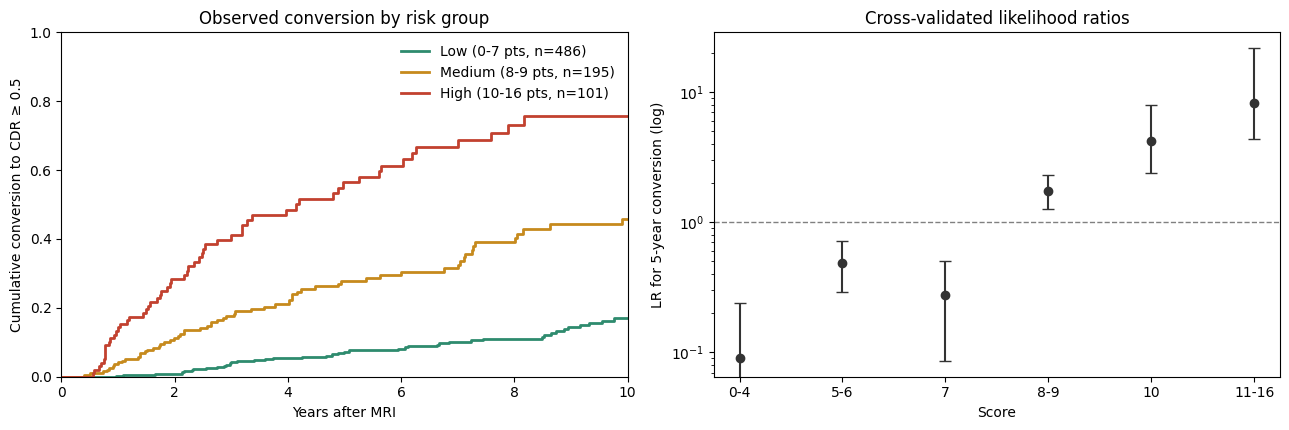

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.4))
cols = {"Low": "#2e8b6e", "Medium": "#c68a1d", "High": "#c2412f"}
for name, lo, hi in GROUPS:
    mk = (sc_all >= lo) & (sc_all <= hi); t, e = s.years.values[mk], s.event.values[mk]
    xs, ys, surv = [0], [0], 1.0
    for tt in np.sort(np.unique(t[e == 1])):
        surv *= 1 - ((t == tt) & (e == 1)).sum() / (t >= tt).sum(); xs += [tt, tt]; ys += [ys[-1], 1 - surv]
    ax[0].step(xs, ys, where="post", color=cols[name], lw=2, label=f"{name} ({lo}-{hi} pts, n={mk.sum()})")
ax[0].set(xlim=(0, 10), ylim=(0, 1), xlabel="Years after MRI", ylabel="Cumulative conversion to CDR ≥ 0.5", title="Observed conversion by risk group")
ax[0].legend(frameon=False)
x = np.arange(len(bands))
ax[1].errorbar(x, bands.LR, yerr=[bands.LR - bands["LR low"], bands["LR high"] - bands.LR], fmt="o", color="#333", capsize=4)
ax[1].axhline(1, color="grey", ls="--", lw=1); ax[1].set_yscale("log"); ax[1].set_xticks(x, bands.index)
ax[1].set(xlabel="Score", ylabel="LR for 5-year conversion (log)", title="Cross-validated likelihood ratios")
fig.tight_layout(); fig.savefig(RESULTS / "future_risk_scale.png", dpi=150); plt.show()

## 7. Score a patient
First, the valid input ranges: the scale only applies to values like those it was built on.

In [ ]:
vol = d.merge(fs[["Subject", "day", "TOTAL_HIPPOCAMPUS_VOLUME", "IntraCranialVol"]],
              left_on=["OASISID", "scan_day"], right_on=["Subject", "day"])
q = [0, .025, .5, .975, 1]
ranges = pd.concat({
    "hippocampus mm3 (all)": vol.TOTAL_HIPPOCAMPUS_VOLUME.quantile(q),
    "hippocampus mm3 (men)": vol.TOTAL_HIPPOCAMPUS_VOLUME[vol.female == 0].quantile(q),
    "hippocampus mm3 (women)": vol.TOTAL_HIPPOCAMPUS_VOLUME[vol.female == 1].quantile(q),
    "intracranial mm3 (all)": vol.IntraCranialVol.quantile(q),
    "intracranial mm3 (men)": vol.IntraCranialVol[vol.female == 0].quantile(q),
    "intracranial mm3 (women)": vol.IntraCranialVol[vol.female == 1].quantile(q),
}, axis=1).T
ranges.columns = ["min", "2.5% (typical low)", "median", "97.5% (typical high)", "max"]
ranges.round(0)

,min,2.5% (typical low),median,97.5% (typical high),max
hippocampus mm3 (all),4012.0,5584.0,7604.0,9525.0,10872.0
hippocampus mm3 (men),4012.0,5688.0,7842.0,9905.0,10872.0
hippocampus mm3 (women),4320.0,5506.0,7524.0,9141.0,9911.0
intracranial mm3 (all),865980.0,1160034.0,1477546.0,1836783.0,2029472.0
intracranial mm3 (men),1198359.0,1359298.0,1632959.0,1914337.0,2029472.0
intracranial mm3 (women),865980.0,1096764.0,1398127.0,1669673.0,1781676.0


Edit the values and run the cell. Volumes are FreeSurfer outputs in mm³. The pre-test probability is your 5-year estimate before the scale.

In [ ]:
# valid input ranges, from the cohort's own FreeSurfer volumes (printed by the cell above)
RANGES = {"hippocampus_mm3": (4010, 10870), "icv_mm3": (870000, 2030000), "age": (42, 97)}

def score_patient(age, educ_years, hippocampus_mm3, icv_mm3, hypertension, depression_2yrs, apoe4, pretest=0.20):
    for name, value in (("age", age), ("hippocampus_mm3", hippocampus_mm3), ("icv_mm3", icv_mm3)):
        lo, hi = RANGES[name]
        if not lo <= value <= hi:
            print(f"WARNING: {name} = {value:,} is outside the cohort range {lo:,}-{hi:,}; the result is an extrapolation.")
    x = pd.DataFrame([{"age": age, "EDUC": educ_years, "hippo_icv": hippocampus_mm3 / icv_mm3 * 1000,
                       "hypertension": int(hypertension), "depression_2yrs": int(depression_2yrs), "apoe4": int(apoe4)}])
    total = int(score(x, NORM).iloc[0]); z = float(zscore(x, "hippo_icv", NORM).iloc[0])
    band = next(n for n, lo, hi in BANDS if lo <= total <= hi)
    group = next(n for n, lo, hi in GROUPS if lo <= total <= hi)
    lr, lo, hi = bands.loc[band, ["LR", "LR low", "LR high"]]
    post = lambda L: (pretest / (1 - pretest) * L) / (1 + pretest / (1 - pretest) * L)
    print(f"hippocampal z-score for age: {z:+.2f}")
    print(f"score {total}/16 -> {group} risk | LR {lr:.2f} (95% CI {lo:.2f}-{hi:.2f})")
    print(f"5-year risk: {pretest:.0%} before -> {post(lr):.0%} after (range {post(lo):.0%}-{post(hi):.0%})")

score_patient(age=72, educ_years=16, hippocampus_mm3=6900, icv_mm3=1_500_000,
              hypertension=True, depression_2yrs=False, apoe4=True, pretest=0.18)

hippocampal z-score for age: -0.78
score 8/16 -> Medium risk | LR 1.74 (95% CI 1.27-2.30)
5-year risk: 18% before -> 28% after (range 22%-34%)


In [ ]:
!cp -r /content/oasis3/results "/content/drive/MyDrive/oasis3_results"

## Save results
Results (tables and figures, no participant-level data) are in `/content/oasis3/results`. To keep them:
```python
!cp -r /content/oasis3/results "/content/drive/MyDrive/oasis3_results"
```
Do not copy the cohort or raw files anywhere shared: the OASIS-3 Data Use Terms forbid redistribution.